# Multi-Encoder U-Net

**Preparing the Environment**

In [4]:
import os
import cv2
import glob
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps  
import zipfile
import tarfile
from zipfile import ZipFile
# neural imaging
# Let's see whether Nilearn is installed
try:
    import nilearn
except ImportError:
    # if not, install it using pip
    !pip install nilearn
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt

# ml libs
import keras
import keras.backend as K
from keras.callbacks import CSVLogger
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.layers.experimental import preprocessing

!pip install synapseclient
import synapseclient

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.5/356.5 kB 6.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 26.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.26.15
    Uninstalling urllib3-1.26.15:
      Successfully uninstalled urllib3-1.26.15
  Attempting uninstall: 

**Upload the Datasets from Synapse**

In [6]:
# installing synapse API 
# get the taraining and validation data and unzip it 
Token = ""put your token
syn = synapseclient.Synapse()
syn.login(authToken=Token)

syn51514132 = syn.get(entity='syn51514132', version=1 )
train_data_path = syn51514132.path
syn51514110 = syn.get(entity='syn51514110', version=1 )
val_data_path = syn51514110.path

print('training_path:', train_data_path)
print('validation_path:', val_data_path)

with ZipFile(train_data_path) as zObject:
    zObject.extractall(
    path='./BraTS2021_Training_Data')
with ZipFile(val_data_path) as zObject:
    zObject.extractall(
    path='./BraTS2021_Validation_Data')

Welcome, Ayoub BOUZARA!

training_path: /root/.synapseCache/453/124663453/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip
validation_path: /root/.synapseCache/768/124662768/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip


In [11]:
VOLUME_SLICES = 75
VOLUME_START_AT = 0 
IMG_SIZE=192

In [12]:
# datapath  = '/kaggle/input/new-dataset-creator-75per-25empty-60aug-crop/BraTS2021_Training_Data.zip'
TRAIN_DATASET_PATH = './BraTS2021_Training_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData'
VALIDATION_DATASET_PATH = './BraTS2021_Validation_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData'

In [13]:
# Extract list of case IDs from dataset directory paths
def extract_ids_from_paths(dir_list):
    ids = []
    for directory in dir_list:
        # Extract the folder name (ID) from the full directory path
        ids.append(directory[directory.rfind('/') + 1:])
    return ids

# Get list of training IDs from the training dataset directory
train_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]
train_ids = extract_ids_from_paths(train_directories)

print("Total number of training cases:", len(train_ids))

Total number of training cases: 1251


In [36]:
# get val_ids list
val_directory = [f.path for f in os.scandir(VALIDATION_DATASET_PATH) if f.is_dir()]
val_ids = extract_ids_from_paths(val_directory)
print("Total number of validation cases:",len(val_ids))

Total number of validation cases: 219


In [14]:
def get_case(case, slice_= 91, preview=None, data_type='training'):
    # Automatically select path based on data_type
    if data_type == 'training':
        path = TRAIN_DATASET_PATH
    elif data_type == 'validation':
        path = VALIDATION_DATASET_PATH
    else:
        raise ValueError("Invalid data_type. Use 'training' or 'validation'.")

    # Define case path
    case_path = os.path.join(path, case)

    # Load images
    data_path = os.path.join(case_path, f'{case}-t2f.nii.gz')
    flair = nib.load(data_path).get_fdata()
    
    data_path = os.path.join(case_path, f'{case}-t1c.nii.gz')
    ce = nib.load(data_path).get_fdata()
    
    data_path = os.path.join(case_path, f'{case}-t1n.nii.gz')
    t1 = nib.load(data_path).get_fdata()
    
    data_path = os.path.join(case_path, f'{case}-t2w.nii.gz')
    t2 = nib.load(data_path).get_fdata()

    # For training: also load the mask
    if data_type == 'training':
        data_path = os.path.join(case_path, f'{case}-seg.nii.gz')
        mask = nib.load(data_path).get_fdata()
    else:
        mask = None  # No mask available for validation

    # Preview if requested
    if preview is not None:
        if data_type == 'training':
            # Display all images with the mask
            fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 10))
        else:
            # Display only the images (no mask)
            fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 10))

        # Axial, Sagittal, or Coronal views
        if preview == 'Axial':
            ax1.imshow(flair[:, :, slice_], cmap='gray')
            ax2.imshow(t1[:, :, slice_], cmap='gray')
            ax3.imshow(ce[:, :, slice_], cmap='gray')
            ax4.imshow(t2[:, :, slice_], cmap='gray')
            if data_type == 'training':
                ax5.imshow(mask[:, :, slice_])

        elif preview == 'Sagital':
            ax1.imshow(flair[slice_, :, :], cmap='gray')
            ax2.imshow(t1[slice_, :, :], cmap='gray')
            ax3.imshow(ce[slice_, :, :], cmap='gray')
            ax4.imshow(t2[slice_, :, :], cmap='gray')
            if data_type == 'training':
                ax5.imshow(mask[slice_, :, :])

        elif preview == 'Coronal':
            ax1.imshow(flair[:, slice_, :], cmap='gray')
            ax2.imshow(t1[:, slice_, :], cmap='gray')
            ax3.imshow(ce[:, slice_, :], cmap='gray')
            ax4.imshow(t2[:, slice_, :], cmap='gray')
            if data_type == 'training':
                ax5.imshow(mask[:, slice_, :])

        # Set titles
        ax1.set_title('Flair')
        ax2.set_title('T1')
        ax3.set_title('T1CE')
        ax4.set_title('T2')
        if data_type == 'training':
            ax5.set_title('Mask')

    # Return images
    if data_type == 'training':
        return flair, ce, t1, t2, mask
    else:
        return flair, ce, t1, t2

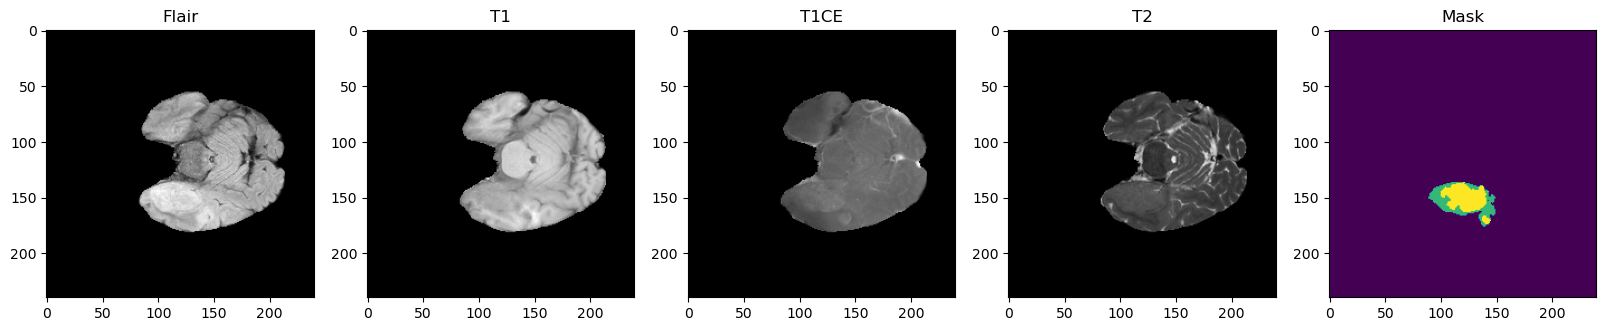

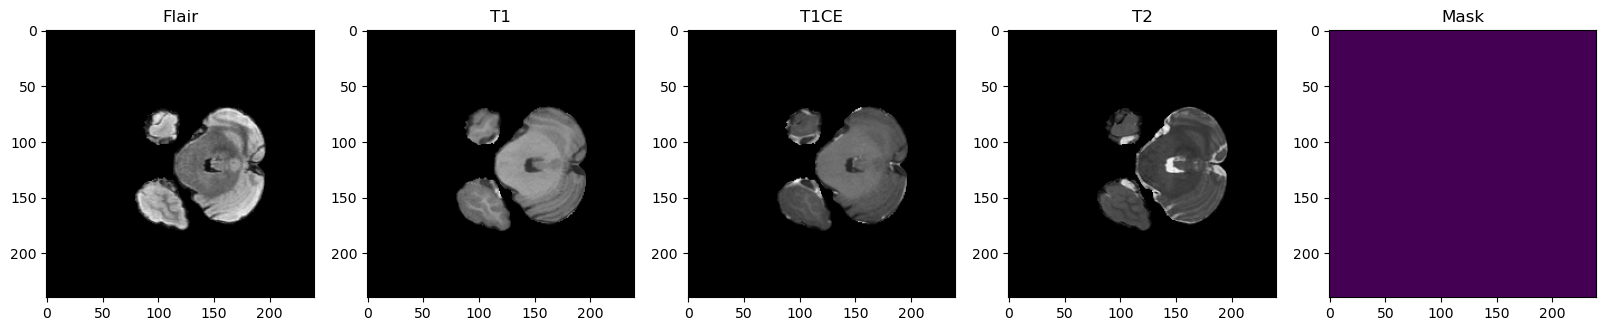

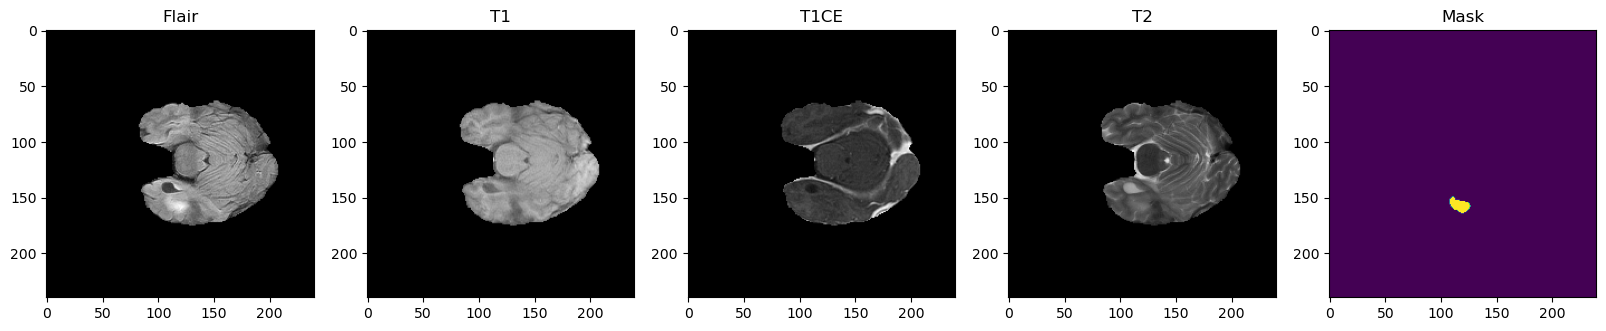

In [15]:
def  preview_cases (list_ids , slice_ = None , preview= 'Axial'):
    for id_ in list_ids:
        flair,ce,t1,t2,mask = get_case(id_, slice_,preview)

preview_cases(train_ids[:3],slice_ = 40,preview = 'Axial')

**Metrics**

In [16]:
# dice loss as defined above for 4 classes
def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = 4
    for i in range(class_num):
        y_true_f = K.flatten(y_true[:,:,:,i])
        y_pred_f = K.flatten(y_pred[:,:,:,i])
        intersection = K.sum(y_true_f * y_pred_f)
        loss = ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))
        if i == 0:
            total_loss = loss
        else:
            total_loss = total_loss + loss
    total_loss = total_loss / class_num
    return total_loss

def dice_coef_loss(y_true, y_pred):
    return 1-dice_coef(y_true, y_pred)

# define per class evaluation of dice coef
# inspired by https://github.com/keras-team/keras/issues/9395
def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,1])) + K.sum(K.square(y_pred[:,:,:,1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,2] * y_pred[:,:,:,2]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,2])) + K.sum(K.square(y_pred[:,:,:,2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,3])) + K.sum(K.square(y_pred[:,:,:,3])) + epsilon)

def dice_tumor_core(y_true, y_pred, epsilon=1e-6):
    intersection_1 = K.sum(K.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    intersection_3 = K.sum(K.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * (intersection_1+intersection_3)) / (K.sum(K.square(y_true[:,:,:,3])) + K.sum(K.square(y_pred[:,:,:,3]))+K.sum(K.square(y_true[:,:,:,1])) + K.sum(K.square(y_pred[:,:,:,1])) + epsilon)
def dice_whole_tumor(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,1:3] * y_pred[:,:,:,1:3]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,1:3])) + K.sum(K.square(y_pred[:,:,:,1:3])) + epsilon)

# Computing Precision 
def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

# Computing Sensitivity      
def sensitivity(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

# Computing Specificity
def specificity(y_true, y_pred):
    true_negatives = K.sum(K.round(K.clip((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

In [17]:
class DataGenerator(tf.keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, dim=(IMG_SIZE,IMG_SIZE), batch_size = 1 , shuffle = True):
        'Initialization'
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.SRC_PATH = TRAIN_DATASET_PATH         # Choosing the right path for train
        self.shuffle = shuffle
        self.on_epoch_end()
        
    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))
    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of IDs
        Batch_ids = [self.list_IDs[k] for k in indexes]
                
        # Generate data
        X, Z,W,y = self.__data_generation(Batch_ids)
        return [X,Z,W],y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        'Generates data containing batch_size samples' # X : (n_samples, *dim, n_channels)
        # Initialization
        X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, 2))
        Z = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, 1))
        W = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, 1))
        y = np.zeros((self.batch_size*VOLUME_SLICES, 240, 240))
        Y = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, 4))

        for c, i in enumerate(Batch_ids):
            case_path = os.path.join(self.SRC_PATH, i)

            data_path = os.path.join(case_path, f'{i}-seg.nii.gz');
            seg = nib.load(data_path).get_fdata()
            
            data_path = os.path.join(case_path, f'{i}-t2f.nii.gz');
            flair = nib.load(data_path).get_fdata()    
            data_path = os.path.join(case_path, f'{i}-t1c.nii.gz');
            ce = nib.load(data_path).get_fdata() 
            data_path = os.path.join(case_path, f'{i}-t1n.nii.gz');
            t1 = nib.load(data_path).get_fdata() 
            data_path = os.path.join(case_path, f'{i}-t2w.nii.gz');
            t2 = nib.load(data_path).get_fdata()
            for j in range(VOLUME_SLICES):
                X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
                X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
                W[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(t1[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
                Z[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(t2[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
                y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT]
                    
        # Generate masks
        y[y==4] = 3;
        mask = tf.one_hot(y, 4);
        Y = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE));
        return (X-X.mean())/X.std(),  (Z-Z.mean())/Z.std(), (W-W.mean())/W.std(), Y

In [18]:
def multi_encoder_unet(inputs,inputs_,inputs__, ker_init, dropout):
# First Encoder (Flair/T1ce)
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(inputs)
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv1)
    
    pool = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)
    
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv2)
    drop2 = Dropout(dropout)(conv2)
    
    pool2 = MaxPooling2D(pool_size=(2, 2))(drop2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv3)
    drop3 = Dropout(dropout)(conv3)
    
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop3)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool4)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv5)
    drop5 = Dropout(dropout)(conv5)

    #############################################################################################################

# Second Encoder (T2)
    conv1_ = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(inputs_)
    conv1_ = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv1_)
    
    pool_ = MaxPooling2D(pool_size=(2, 2))(conv1_)
    conv_ = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool_)
    conv_ = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv_)
    
    pool1_ = MaxPooling2D(pool_size=(2, 2))(conv_)
    conv2_ = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool1_)
    conv2_ = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv2_)
    drop2_ = Dropout(dropout)(conv2_)
    
    pool2_ = MaxPooling2D(pool_size=(2, 2))(drop2_)
    conv3_ = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool2_)
    conv3_ = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv3_)
    drop3_ = Dropout(dropout)(conv3_)
    
    #############################################################################################################
    
# Third Encoder (T1) 
    conv1__ = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(inputs__)
    conv1__ = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv1__)
    
    pool__ = MaxPooling2D(pool_size=(2, 2))(conv1__)
    conv__ = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool__)
    conv__ = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv__)
    
    pool1__ = MaxPooling2D(pool_size=(2, 2))(conv__)
    conv2__ = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool1__)
    conv2__ = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv2__)
    drop2__ = Dropout(dropout)(conv2__)
    
    pool2__ = MaxPooling2D(pool_size=(2, 2))(drop2__)
    conv3__ = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool2__)
    conv3__ = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv3__)
    drop3__ = Dropout(dropout)(conv3__)    
    #############################################################################################################
    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(drop5))
    merge7 = concatenate([up7,drop3,drop3_,drop3__], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv7)
    
    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([up8,drop2,drop2_,drop2__], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([up9,conv,conv_,conv__], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv9)
    
    up = Conv2D(32, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv9))
    merge = concatenate([up,conv1,conv1_,conv1__], axis = 3)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)
    conv10 = Conv2D(4, (1,1), activation = 'softmax')(conv)

    return Model(inputs = [inputs,inputs_,inputs__], outputs = conv10)

input_layer = Input((IMG_SIZE, IMG_SIZE,2))
input_layer_ = Input((IMG_SIZE, IMG_SIZE,1))
input_layer__ = Input((IMG_SIZE, IMG_SIZE,1))

model = multi_encoder_unet(input_layer,input_layer_,input_layer__, 'he_normal', 0.2)

model.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003), metrics = ['accuracy', dice_coef,
                                                                                                                    dice_coef_necrotic, dice_coef_edema ,
                                                                                                                    dice_coef_enhancing,dice_tumor_core,
                                                                                                                   dice_whole_tumor])

In [19]:
wspace_path = "./"
wspace_path2 = "/kaggle/input/109-w08-model"
wspace_path3 = "./folder/"

In [20]:
# Init Params
train_ = False  # Set to True if you want to train the model from scratch
load_ = True   # Set to True if you want to load a pretrained model

# Ensure that only one option is selected
if train_ and load_:
    raise ValueError("You must choose either to train the model from scratch or to load a pretrained model, not both.")

if train_:
    # Prepare the data generator for training
    train_generator = DataGenerator(train_ids)
    
    # # Monitoring the training process with WandB
    # wandb.login(key='put your key')
    # run = wandb.init(project='Brain Tumor Segmentation 3-Encoder to 1-Decoder',
    #                  config={
    #                      "activation": "relu",
    #                      "optimizer": "Adam",
    #                      "loss": "categorical_crossentropy",
    #                      "metric": "accuracy",
    #                      "batch_size": 1,
    #                      "notes": "109_W08"
    #                      }
    #                  )
    # config = wandb.config

    # Define a scheduler for learning rate decay
    def scheduler(epoch, lr):
        if epoch < 20:
            return 0.0003
        elif epoch < 25:
            return 0.00015
        elif epoch < 29:
            return 0.000075
        elif epoch < 33:
            return 0.0000375
        else:
            return 0.000002

    # Create callbacks for training
    csv_logger = CSVLogger(wspace_path+'/training0.log', separator=',', append=False)
    callbacks = [
        keras.callbacks.LearningRateScheduler(scheduler),
        csv_logger,
        # WandbCallback(),
    ]
    
    # Launch training 
    K.clear_session()
    history = model.fit(train_generator,
                        epochs=42,
                        steps_per_epoch=len(train_ids),
                        callbacks=callbacks)
    
    # Save the trained model
    model.save(wspace_path+"/model.h5")
    hist = history.history

elif load_:
    # Load the pretrained model
    shutil.copy('/kaggle/input/brats-23-adult-glioma-wood/modelC.h5', wspace_path)

    model = keras.models.load_model(wspace_path+"/modelC.h5", 
                                    custom_objects={"dice_coef": dice_coef,
                                                    "dice_coef_necrotic": dice_coef_necrotic,
                                                    "dice_coef_edema": dice_coef_edema,
                                                    "dice_coef_enhancing": dice_coef_enhancing,
                                                    "dice_tumor_core": dice_tumor_core,
                                                    "dice_whole_tumor": dice_whole_tumor
                                                   }, compile=False)

else:
    raise ValueError("You must choose to either train the model or load a pretrained model.")

In [57]:
def seg_case(case, slice_=50, preview=None, data_type='training', save_segmentation=False):
    # Automatically select path based on data_type
    if data_type == 'training':
        path = TRAIN_DATASET_PATH
    elif data_type == 'validation':
        path = VALIDATION_DATASET_PATH
    else:
        raise ValueError("Invalid data_type. Use 'training' or 'validation'.")

    # Define case path
    case_path = os.path.join(path, case)

    # Load images
    data_path = os.path.join(case_path, f'{case}-t2f.nii.gz')
    flair = nib.load(data_path).get_fdata()
    
    data_path = os.path.join(case_path, f'{case}-t1c.nii.gz')
    ce = nib.load(data_path).get_fdata()
    
    data_path = os.path.join(case_path, f'{case}-t1n.nii.gz')
    t1 = nib.load(data_path).get_fdata()
    
    data_path = os.path.join(case_path, f'{case}-t2w.nii.gz')
    t2 = nib.load(data_path).get_fdata()

    # For training: also load the mask
    if data_type == 'training':
        data_path = os.path.join(case_path, f'{case}-seg.nii.gz')
        mask = nib.load(data_path).get_fdata()
    else:
        mask = None  # No mask available for validation

    # Resizing and preparing data for model prediction
    X = np.zeros((155, IMG_SIZE, IMG_SIZE, 2))
    Z = np.zeros((155, IMG_SIZE, IMG_SIZE, 1))
    W = np.zeros((155, IMG_SIZE, IMG_SIZE, 1))
    
    for j in range(155):
        X[j, :, :, 0] = cv2.resize(flair[:, :, j], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 1] = cv2.resize(ce[:, :, j], (IMG_SIZE, IMG_SIZE))
        W[j, :, :, 0] = cv2.resize(t1[:, :, j], (IMG_SIZE, IMG_SIZE))
        Z[j, :, :, 0] = cv2.resize(t2[:, :, j], (IMG_SIZE, IMG_SIZE))
    
    # Predict segmentation using the model
    p = model.predict([(X - X.mean()) / X.std(), (Z - Z.mean()) / Z.std(), (W - W.mean()) / W.std()])
    print("p ", p.shape)
    test_p = np.swapaxes(tf.argmax(p, axis=3), 0, 1)
    print("test_p ", test_p.shape)

    img_seg = np.zeros((240, 240, 155, 4))
    img_seg[24:216, 24:216, :, :] = np.swapaxes(p, 0, 2)
    print (img_seg.shape)
    print (flair.shape)

    predicted_segmentation = tf.argmax(img_seg, axis=3)
    img_seg_ass = np.round(predicted_segmentation)
    print (img_seg_ass.shape)

    # Optionally save the segmented image
    if save_segmentation:
        os.mkdir(wspace_path3)
        img_seg_ass_converted = np.array(img_seg_ass).astype(np.int64)
        ni_img = nib.Nifti1Image(img_seg_ass_converted, affine=None, dtype=np.int64)
        nib.save(ni_img, wspace_path3 + f"{case}_segmentation.nii.gz")
    
    # Preview if requested
    if preview is not None:
        if data_type == 'training':
            # Display 6 images including the mask for training data
            fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(1, 6, figsize=(25, 10))
        else:
            # Display 5 images without the mask for validation data
            fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(25, 10))

        # Axial, Sagittal, or Coronal views
        if preview == 'Axial':
            ax1.imshow(flair[:, :, slice_], cmap='gray')
            ax2.imshow(t1[:, :, slice_], cmap='gray')
            ax3.imshow(ce[:, :, slice_], cmap='gray')
            ax4.imshow(t2[:, :, slice_], cmap='gray')
            ax5.imshow(test_p[slice_,:, :])  # Predicted segmentation
            if data_type == 'training':
                ax6.imshow(mask[:, :, slice_])  # Mask (only for training)

        elif preview == 'Sagital':
            ax1.imshow(flair[slice_, :, :], cmap='gray')
            ax2.imshow(t1[slice_, :, :], cmap='gray')
            ax3.imshow(ce[slice_, :, :], cmap='gray')
            ax4.imshow(t2[slice_, :, :], cmap='gray')
            ax5.imshow(img_seg_ass[slice_, :, :])
            if data_type == 'training':
                ax6.imshow(mask[slice_, :, :])

        elif preview == 'Coronal':
            ax1.imshow(flair[:, slice_, :], cmap='gray')
            ax2.imshow(t1[:, slice_, :], cmap='gray')
            ax3.imshow(ce[:, slice_, :], cmap='gray')
            ax4.imshow(t2[:, slice_, :], cmap='gray')
            ax5.imshow(img_seg_ass[:, slice_, :])
            if data_type == 'training':
                ax6.imshow(mask[:, slice_, :])

        # Set titles
        ax1.set_title('Flair')
        ax2.set_title('T1')
        ax3.set_title('T1CE')
        ax4.set_title('T2')
        ax5.set_title('Predicted Segmentation')
        if data_type == 'training':
            ax6.set_title('Mask')

5/5 [==============================] - 0s 87ms/step
p  (155, 192, 192, 4)
test_p  (155, 192, 192)
(240, 240, 155, 4)
(240, 240, 155)
(240, 240, 155)
5/5 [==============================] - 0s 95ms/step
p  (155, 192, 192, 4)
test_p  (155, 192, 192)
(240, 240, 155, 4)
(240, 240, 155)
(240, 240, 155)
5/5 [==============================] - 0s 88ms/step
p  (155, 192, 192, 4)
test_p  (155, 192, 192)
(240, 240, 155, 4)
(240, 240, 155)
(240, 240, 155)


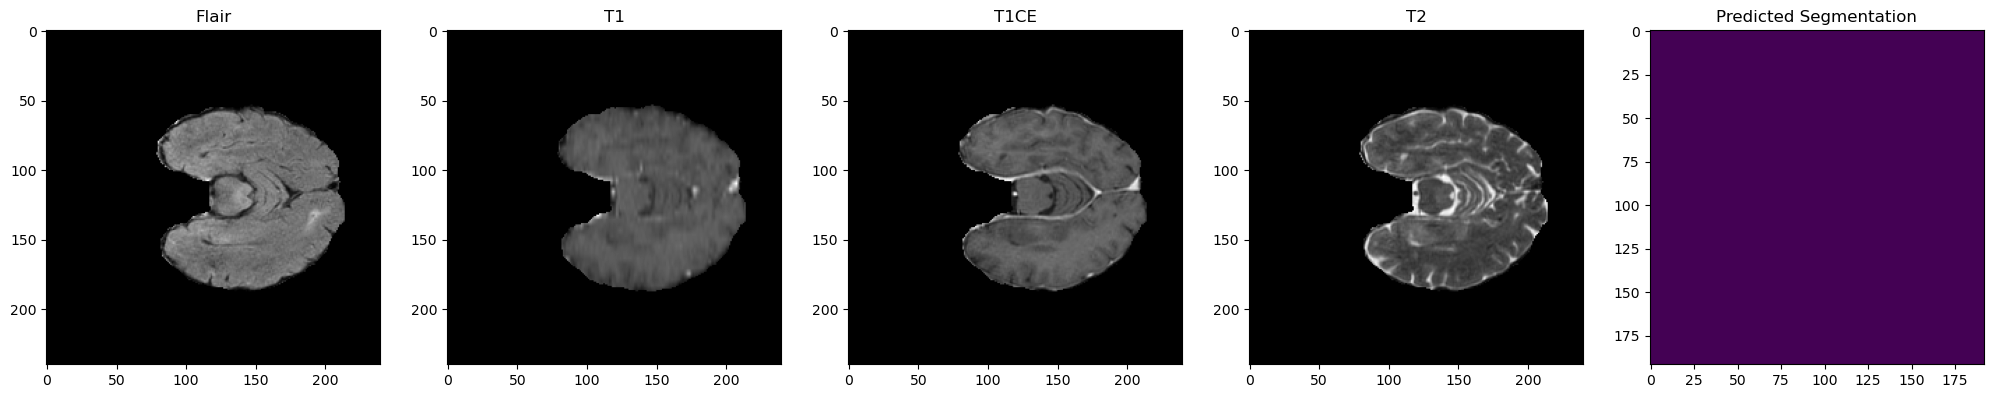

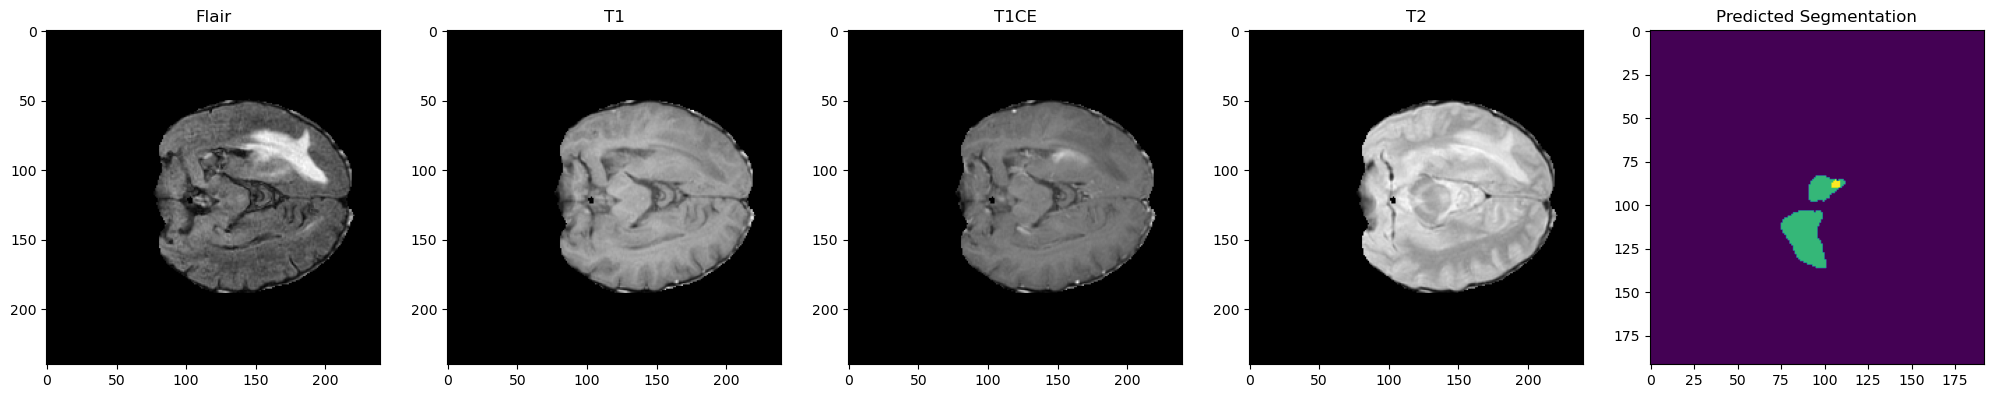

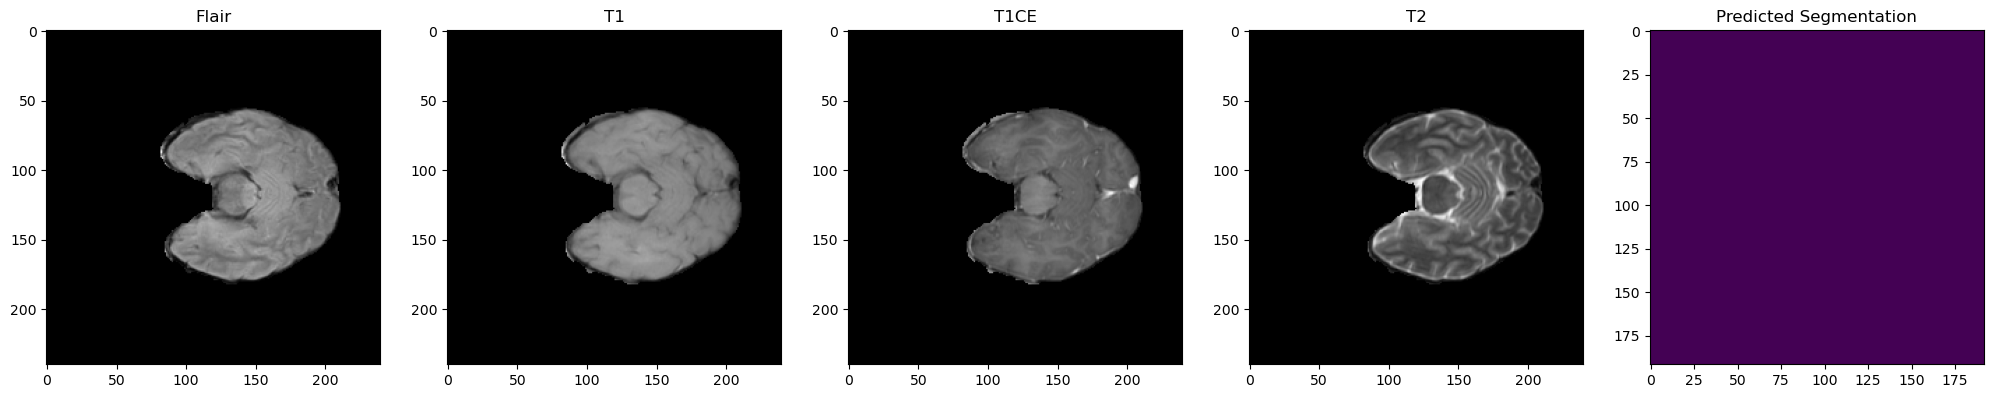

In [55]:
for id_ in val_ids[:3]:
     seg_case(id_, data_type='validation', preview = 'Axial')

5/5 [==============================] - 0s 92ms/step
p  (155, 192, 192, 4)
test_p  (155, 192, 192)
(240, 240, 155, 4)
(240, 240, 155)
(240, 240, 155)
5/5 [==============================] - 0s 98ms/step
p  (155, 192, 192, 4)
test_p  (155, 192, 192)
(240, 240, 155, 4)
(240, 240, 155)
(240, 240, 155)
5/5 [==============================] - 1s 118ms/step
p  (155, 192, 192, 4)
test_p  (155, 192, 192)
(240, 240, 155, 4)
(240, 240, 155)
(240, 240, 155)


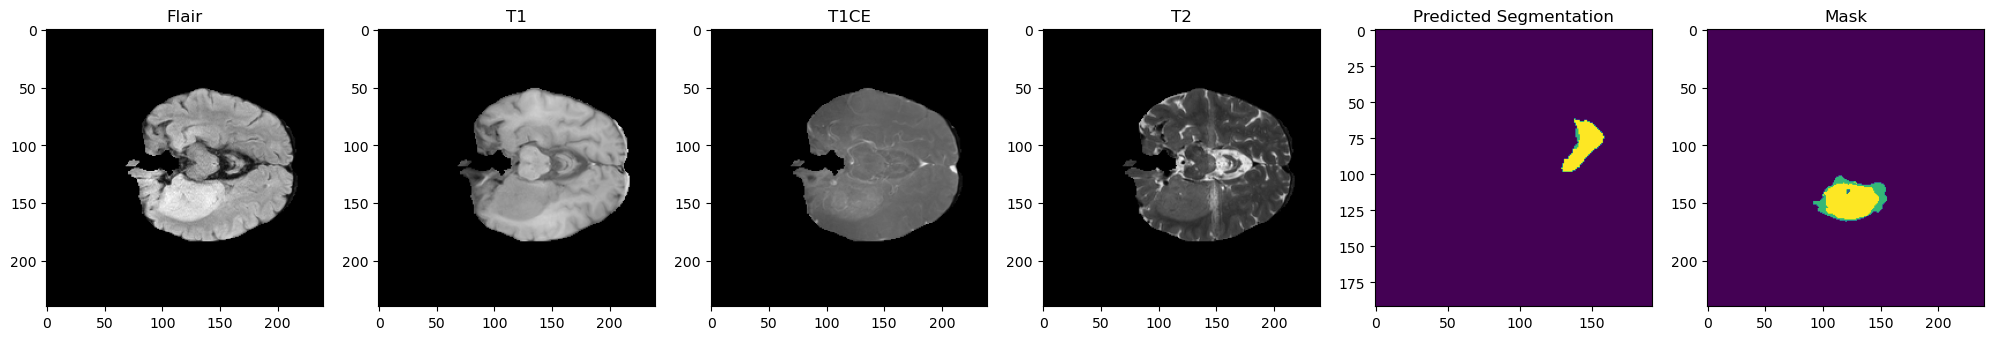

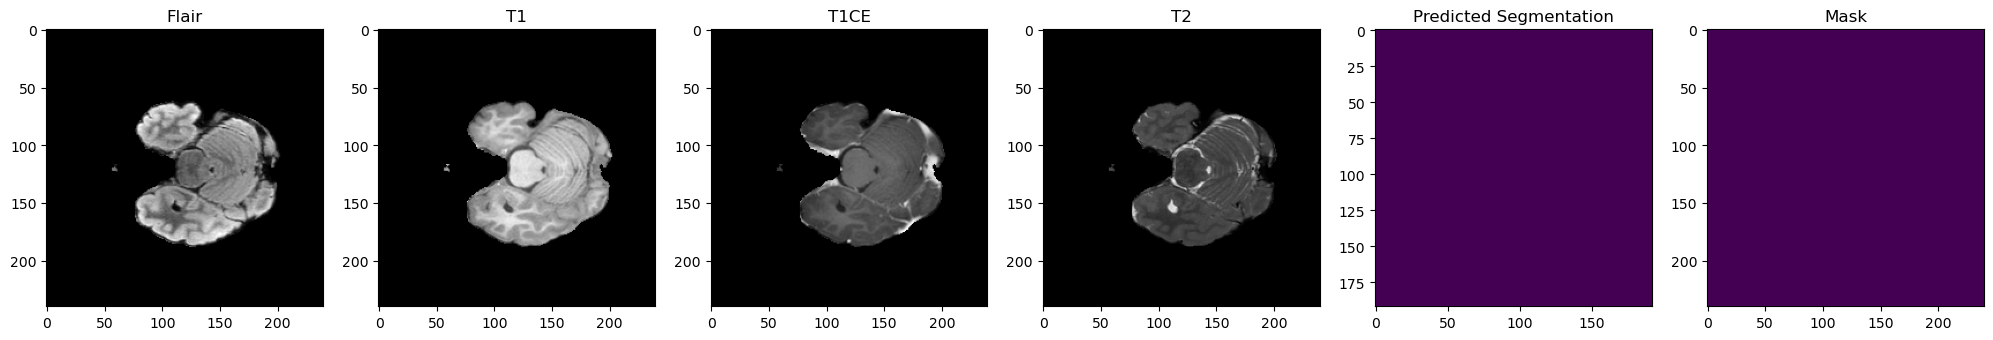

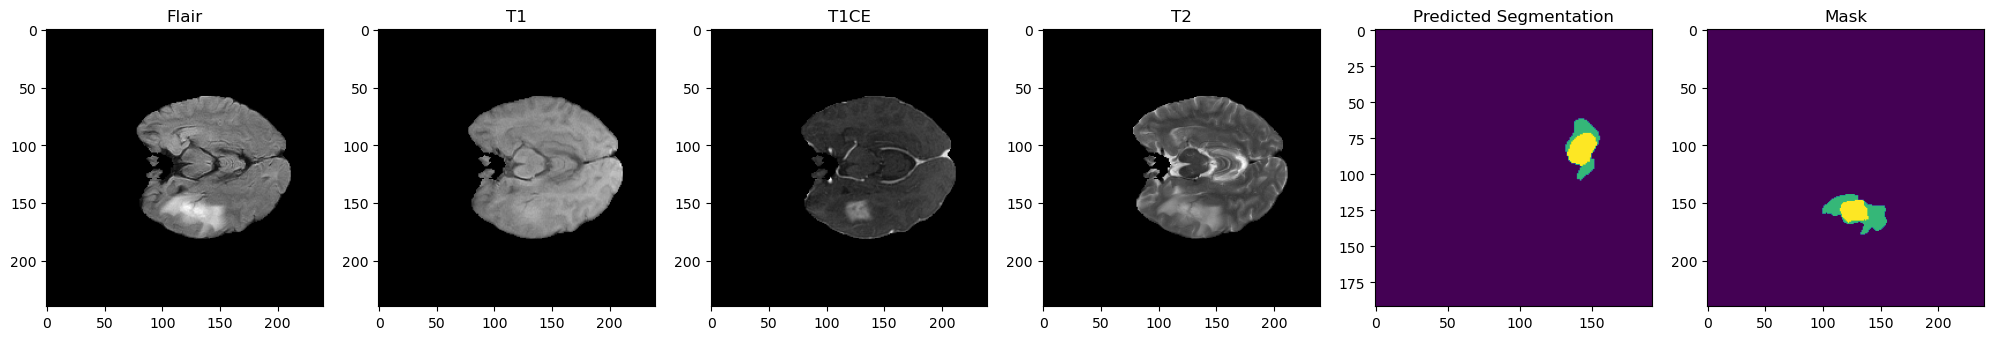

In [56]:
for id_ in train_ids[:3]:
     seg_case(id_, data_type='training', preview = 'Axial')